In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import GridSearchCV

In [4]:
data = pd.read_csv('advertising.csv')
data

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0
...,...,...,...,...,...,...,...,...,...,...
995,72.97,30,71384.57,208.58,Fundamental modular algorithm,Duffystad,1,Lebanon,2016-02-11 21:49:00,1
996,51.30,45,67782.17,134.42,Grass-roots cohesive monitoring,New Darlene,1,Bosnia and Herzegovina,2016-04-22 02:07:01,1
997,51.63,51,42415.72,120.37,Expanded intangible solution,South Jessica,1,Mongolia,2016-02-01 17:24:57,1
998,55.55,19,41920.79,187.95,Proactive bandwidth-monitored policy,West Steven,0,Guatemala,2016-03-24 02:35:54,0


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   str    
 5   City                      1000 non-null   str    
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   str    
 8   Timestamp                 1000 non-null   str    
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 78.3 KB


In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.describe(include = 'all')

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000,1000.000000,1000,1000,1000.00000
unique,NaN,NaN,NaN,NaN,1000,969,NaN,237,1000,NaN
top,NaN,NaN,NaN,NaN,Cloned 5thgeneration orchestration,Lisamouth,NaN,Czech Republic,2016-03-27 00:53:11,NaN
freq,NaN,NaN,NaN,NaN,1,3,NaN,9,1,NaN
mean,65.000200,36.009000,55000.000080,180.000100,NaN,NaN,0.481000,NaN,NaN,0.50000
std,15.853615,8.785562,13414.634022,43.902339,NaN,NaN,0.499889,NaN,NaN,0.50025
min,32.600000,19.000000,13996.500000,104.780000,NaN,NaN,0.000000,NaN,NaN,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,NaN,NaN,0.000000,NaN,NaN,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,NaN,NaN,0.000000,NaN,NaN,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,NaN,NaN,1.000000,NaN,NaN,1.00000


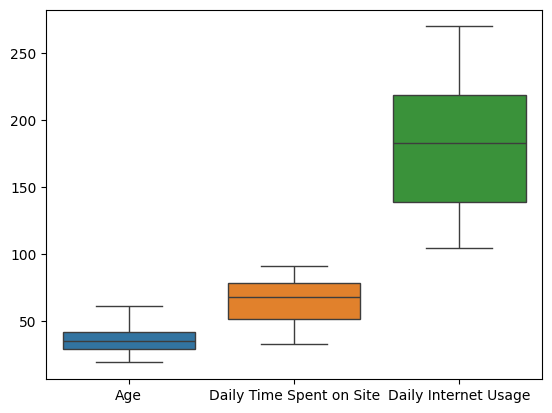

In [8]:
sns.boxplot(data[['Age', 'Daily Time Spent on Site', 'Daily Internet Usage']])
plt.show()

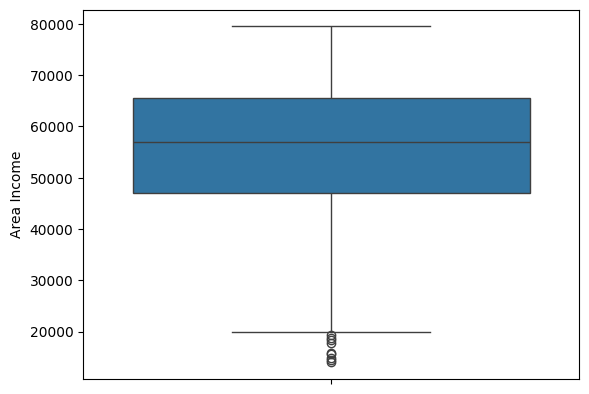

In [9]:
sns.boxplot(data['Area Income'])
plt.show()

In [10]:
print(data['Ad Topic Line'].unique().size)
print(data['City'].unique().size)
print(data['Country'].unique().size)
print()
print(data['Clicked on Ad'].value_counts())

1000
969
237

Clicked on Ad
0    500
1    500
Name: count, dtype: int64


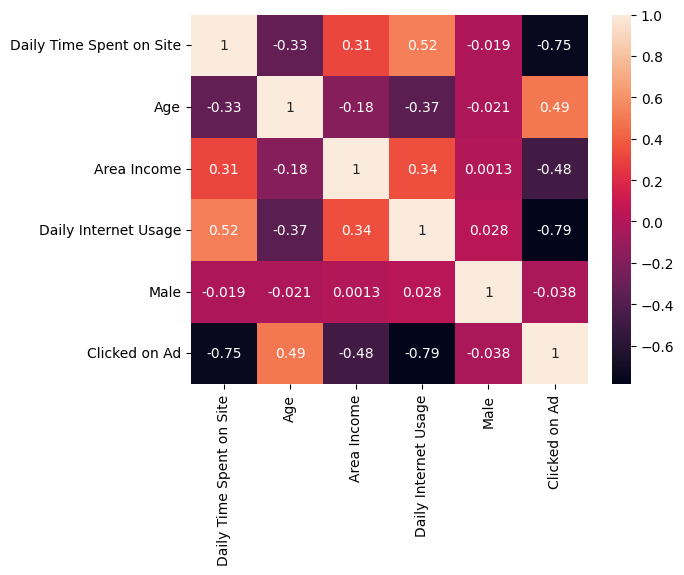

In [11]:
numeric_data = data.select_dtypes(include=np.number)
corr = numeric_data.corr()
sns.heatmap(corr, annot = True)
plt.show()

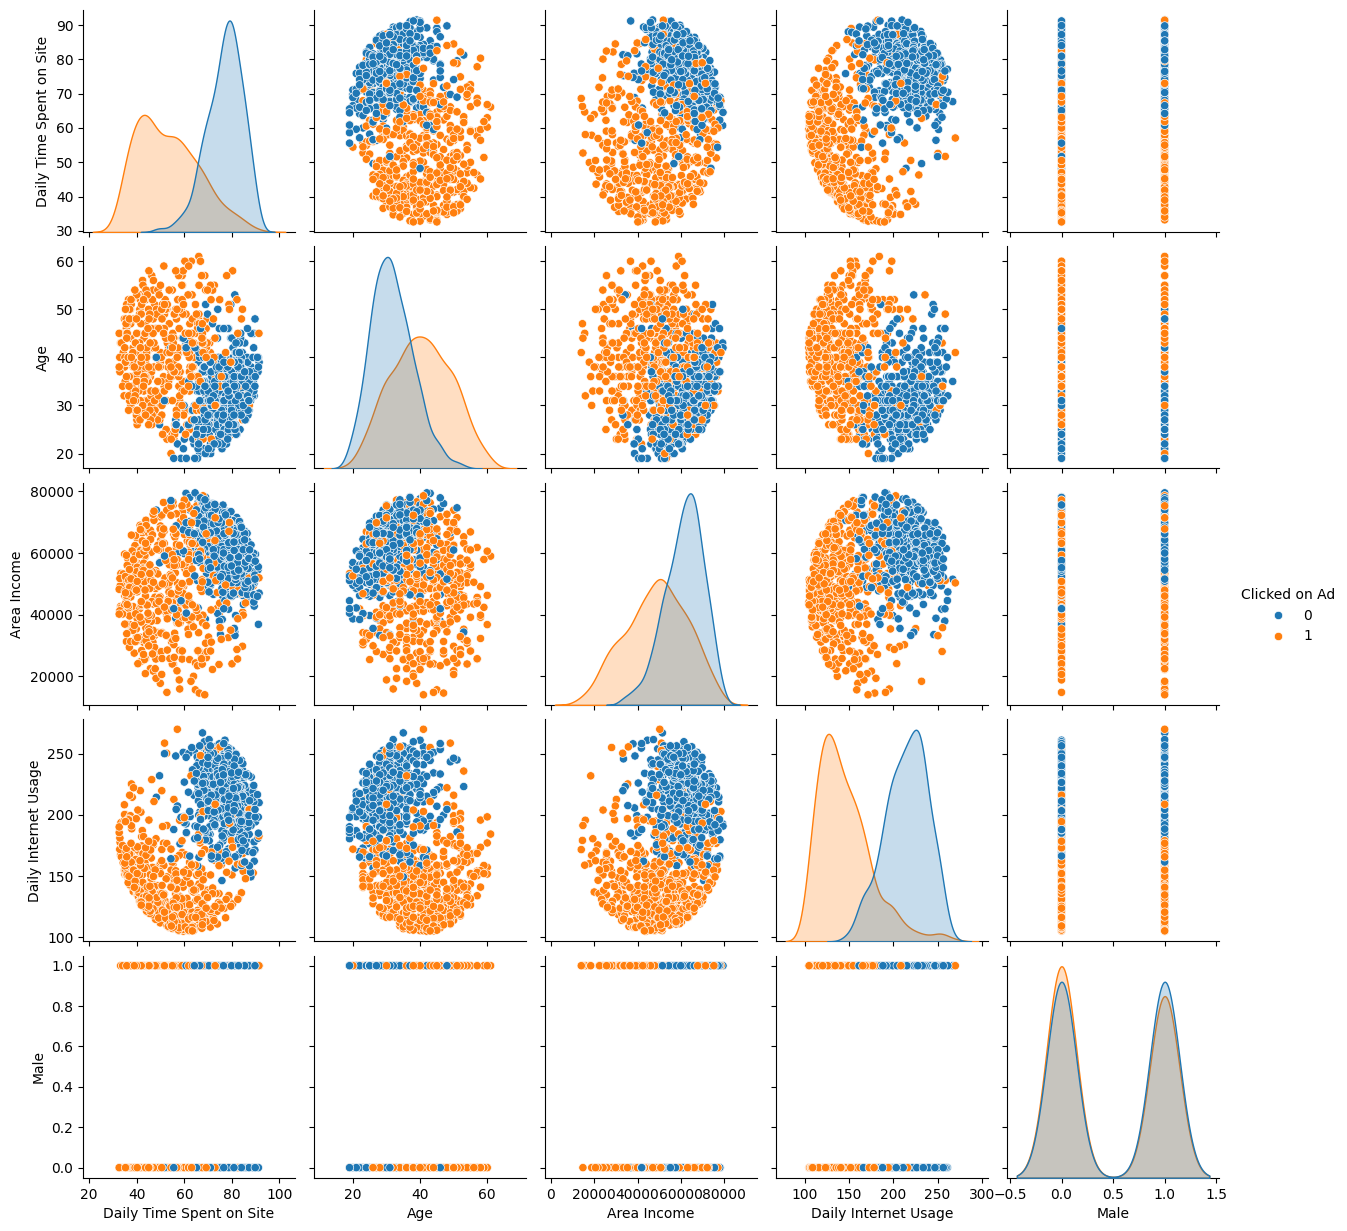

In [12]:
sns.pairplot(data, hue="Clicked on Ad")

In [13]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

def classify_day_night(timestamp):
    hour = timestamp.hour
    if 6 <= hour < 18:
        return 1
    else:
        return 0

data['Period'] = data['Timestamp'].apply(classify_day_night)
data = data.drop(columns=['Timestamp'])

In [14]:
x = data.drop("Clicked on Ad", axis=1)
y = data["Clicked on Ad"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 40)

In [15]:
# Define columns for transformations
pca_cols = ['Daily Time Spent on Site', 'Daily Internet Usage']
qt_cols = ['Age', 'Area Income']
other_cols = ['Male', 'Period']

# Create the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('pca', Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=1))
        ]), pca_cols),
        ('quantile', QuantileTransformer(output_distribution='normal'), qt_cols),
        ('passthrough', 'passthrough', other_cols)
    ],
    remainder='drop'  # Drops any columns not explicitly listed
)

x_train_transformed = preprocessor.fit_transform(x_train)
x_test_transformed = preprocessor.transform(x_test)

# Get feature names after transformation
feature_names = (
    ['PCAed time spend'] +  # From PCA
    qt_cols +          # From QuantileTransformer
    other_cols         # Passed through
)

# ==============================
# Convert back to DataFrames
# ==============================
x_train = pd.DataFrame(
    x_train_transformed,
    columns=feature_names,
    index=x_train.index
)

x_test = pd.DataFrame(
    x_test_transformed,
    columns=feature_names,
    index=x_test.index
)

# Display the results
display(x_train.head())
display(x_test.head())

d:\Rahul Work\PythonModule4\.venv\Lib\site-packages\sklearn\preprocessing\_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (800). n_quantiles is set to n_samples.
  warnings.warn(


,PCAed time spend,Age,Area Income,Male,Period
970,-1.533503,-0.697313,-0.418140,0.0,0.0
137,-1.845562,0.309164,-0.881638,1.0,0.0
82,-1.390291,0.309164,0.377392,0.0,1.0
188,0.468819,-0.561483,-1.024961,0.0,1.0
358,-0.930222,2.534398,-0.890931,0.0,1.0


,PCAed time spend,Age,Area Income,Male,Period
204,0.863385,-0.697313,1.291296,0.0,0.0
71,0.891680,1.019670,1.900661,0.0,1.0
594,-1.377359,0.309164,1.009108,1.0,0.0
672,1.589701,-0.206955,-0.781784,0.0,1.0
14,-1.547316,-0.206955,-1.516214,0.0,1.0


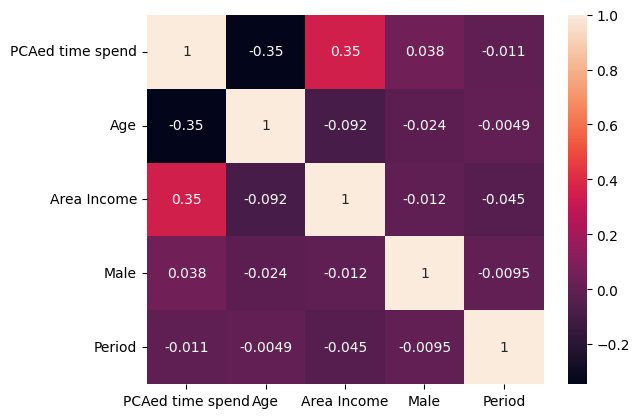

In [16]:
corr = x_train.corr()
sns.heatmap(corr, annot = True)
plt.show()

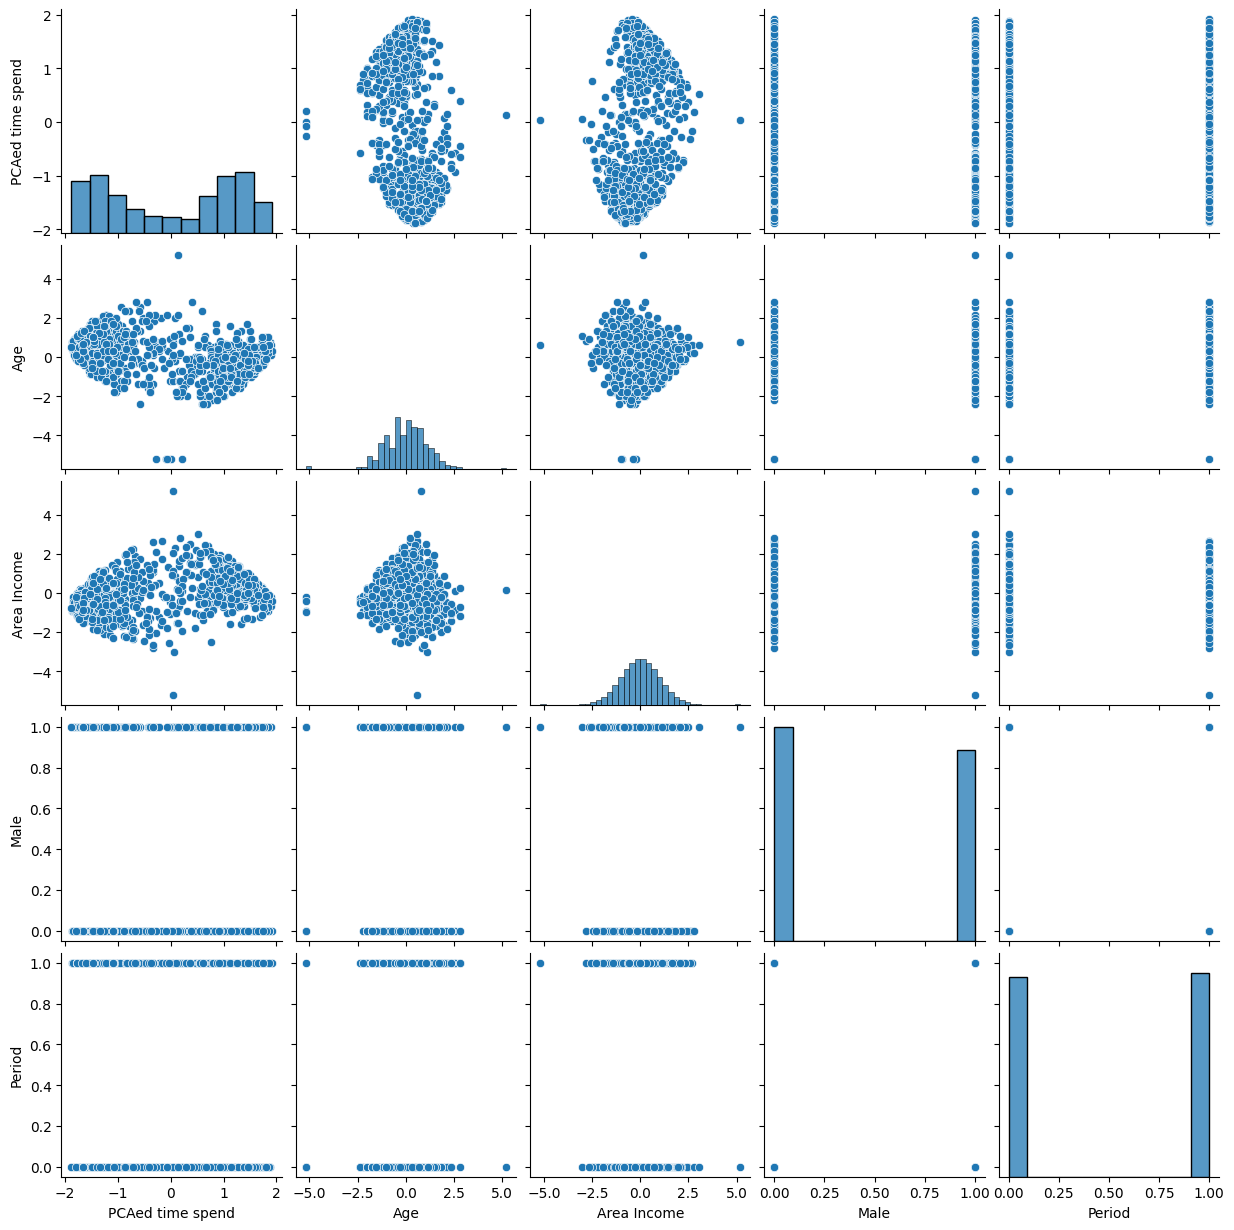

In [17]:
sns.pairplot(x_train)

In [18]:
# ==============================
# Hyperparameter grids
# ==============================

param_grids = {

    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"],
        "max_iter": [200, 500]
    },

    "XGBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5, 7]
    },

    "LightGBM": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5, 7]
    }
}

In [19]:
# lr = LogisticRegression()

# lr.fit(x_train, y_train)
# y_test_predict = lr.predict(x_test)
# y_train_predict = lr.predict(x_train)

# print('-------------------Logistic Regression-------------------------')
# print("accuracy for train = ", accuracy_score(y_train, y_train_predict))
# print("accuracy for test = ", accuracy_score(y_test, y_test_predict))

# print(metrics.classification_report(y_test, y_test_predict))

# print('Confusion matrix')
# print(metrics.confusion_matrix(y_test, y_test_predict))

# ==============================
# Models
# ==============================

models = {
    "Logistic Regression": LogisticRegression(),
    
    "XGBoost": XGBClassifier(
        random_state=0,
        eval_metric='logloss'
    ),

    "LightGBM": LGBMClassifier(
        random_state=0
    )
}

best_models = {}

In [20]:
# xgb = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=0)

# # Train the model
# xgb.fit(x_train, y_train)

# # Make predictions on the test set
# xgb_y_predict_test = xgb.predict(x_test)
# xgb_y_train_predict = xgb.predict(x_train)

# print('-----------XGB Classifier-----------')
# print("accuracy for train = ", accuracy_score(y_train, xgb_y_train_predict))
# print("accuracy for test = ", accuracy_score(y_test, xgb_y_predict_test))
# print(metrics.classification_report(y_test, xgb_y_predict_test))

# print('Confusion matrix')
# print(metrics.confusion_matrix(y_test, xgb_y_predict_test))

# ==============================
# Hyperparameter tuning
# ==============================

for name in models:

    print(f"\nTuning {name}...")

    grid = GridSearchCV(
        estimator=models[name],
        param_grid=param_grids[name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(x_train, y_train)

    best_models[name] = grid.best_estimator_

    print("Best Parameters:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)


Tuning Logistic Regression...


Best Parameters: {'C': 0.1, 'max_iter': 200, 'solver': 'lbfgs'}
Best CV Score: 0.9724999999999999

Tuning XGBoost...
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV Score: 0.9625

Tuning LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 412, number of negative: 388
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 556
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515000 -> initscore=0.060018
[LightGBM] [Info] Start training from score 0.060018
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

In [21]:
# # Probability scores
# xgb_probs = xgb.predict_proba(x_test)[:, 1]
# lr_probs = lr.predict_proba(x_test)[:, 1]

# # ROC values
# xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
# lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

# # AUC scores
# xgb_auc = auc(xgb_fpr, xgb_tpr)
# lr_auc = auc(lr_fpr, lr_tpr)

# # Plot ROC Curve
# plt.figure(figsize=(8,6))

# plt.plot(xgb_fpr, xgb_tpr,
#          label=f'XGBoost (AUC = {xgb_auc:.2f})')

# plt.plot(lr_fpr, lr_tpr,
#          label=f'Logistic Regression (AUC = {lr_auc:.2f})')

# # Random classifier line
# plt.plot([0,1], [0,1], linestyle='--')

# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve')

# plt.legend()
# plt.show()

# ==============================
# Evaluation
# ==============================

for name, model in best_models.items():

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    print(f"\n----------- {name} -----------")

    print("Train Accuracy:",
          accuracy_score(y_train, y_train_pred))

    print("Test Accuracy:",
          accuracy_score(y_test, y_test_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_test_pred))

    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_test_pred))


----------- Logistic Regression -----------
Train Accuracy: 0.97125
Test Accuracy: 0.985

Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       112
           1       1.00      0.97      0.98        88

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200

Confusion Matrix
[[112   0]
 [  3  85]]

----------- XGBoost -----------
Train Accuracy: 1.0
Test Accuracy: 0.98

Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       112
           1       1.00      0.95      0.98        88

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200

Confusion Matrix
[[112   0]
 [  4  84]]

----------- LightGBM -----------
Train Accuracy: 0.97625

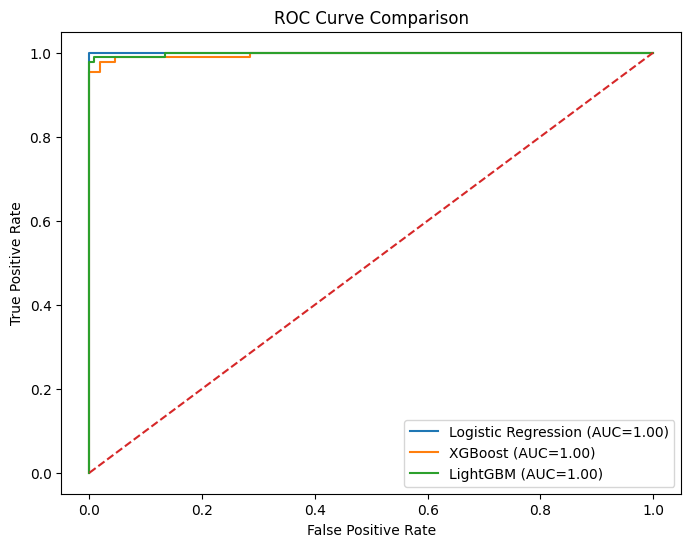

In [22]:
# ==============================
# ROC Curve
# ==============================

plt.figure(figsize=(8,6))

for name, model in best_models.items():

    probs = model.predict_proba(x_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probs)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC={roc_auc:.2f})'
    )

# random classifier
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [32]:
# ==============================
# Choose best model
# ==============================
best_model = best_models["Logistic Regression"]

In [33]:
# ==============================
# One new data point
# ==============================
new_data = pd.DataFrame([{
    "Daily Time Spent on Site": 60.5,
    "Age": 32,
    "Area Income": 55000,
    "Daily Internet Usage": 210.5,
    "Ad Topic Line": "Robust scalable platform",
    "City": "New Delhi",
    "Male": 1,
    "Country": "India",
    "Timestamp": "2016-06-15 10:30:00"
}])

In [34]:
new_data['Timestamp'] = pd.to_datetime(new_data['Timestamp'])
new_data['Period'] = new_data['Timestamp'].apply(classify_day_night)
new_data = new_data.drop(columns=['Timestamp'])

In [35]:
# ==============================
# Apply same preprocessing
# ==============================
new_data_transformed = preprocessor.transform(new_data)

new_data_transformed = pd.DataFrame(
    new_data_transformed,
    columns=feature_names
)

In [36]:
# ==============================
# Prediction
# ==============================
prediction = best_model.predict(new_data_transformed)

# Probability
probability = best_model.predict_proba(new_data_transformed)

print("Predicted class =", prediction[0])
print("Prediction probability =", probability)

Predicted class = 0
Prediction probability = [[0.53338533 0.46661467]]
